In [1]:
import torch
import torchvision #это для преобразований

from torchvision import transforms
from torchsummary import summary

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [6]:
transform = transforms.Compose([transforms.ToTensor()]) # преобразование из картинки в тензор

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)

classes = tuple(str(i) for i in range(10))

In [10]:
trainloader.dataset.data.shape

torch.Size([60000, 28, 28])

In [11]:
testloader.dataset.data.shape

torch.Size([10000, 28, 28])

Выведем первую ячейку

In [16]:
trainloader.dataset.train_data[0]

/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

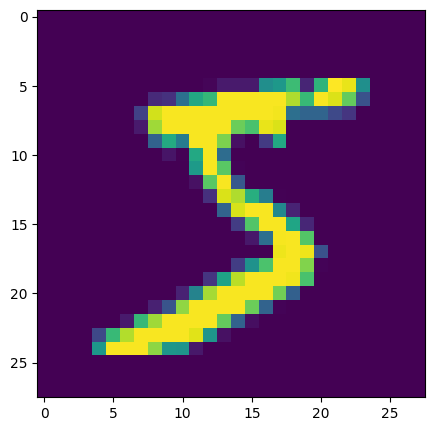

In [18]:
img = trainloader.dataset.train_data[0].numpy()
fig = plt.figure(figsize=(5, 7))
plt.imshow(img)

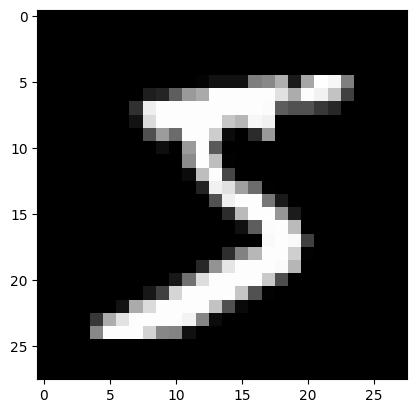

In [19]:
plt.imshow(img, cmap='gray')

In [20]:
for data in trainloader:
  print(data)
  break

[tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
   

Теперь вспомним, что в PyTorch есть две парадигмы построения сетей - Functional и Sequantial. Будем использовать первый метод

In [28]:
import torch.nn as nn
import torch.nn.functional as F

In [42]:
class SimpleConvNet(nn.Module):
  def __init__(self):
    super(SimpleConvNet, self).__init__()
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
    self.fc1 = nn.Linear(4*4*16, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = x.view(-1, 4 * 4 * 16)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [43]:
net = SimpleConvNet().to(device)

summary(net.cuda(), (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 24, 24]             156
         MaxPool2d-2            [-1, 6, 12, 12]               0
            Conv2d-3             [-1, 16, 8, 8]           2,416
         MaxPool2d-4             [-1, 16, 4, 4]               0
            Linear-5                  [-1, 120]          30,840
            Linear-6                   [-1, 84]          10,164
            Linear-7                   [-1, 10]             850
Total params: 44,426
Trainable params: 44,426
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 0.17
Estimated Total Size (MB): 0.22
----------------------------------------------------------------


In [45]:
loss_fn = torch.nn.CrossEntropyLoss()
learning_rate=1e-4
optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)

In [46]:
import tqdm
from tqdm.auto import tqdm

losses = []
for epoch in tqdm(range(2)):
  running_loss = 0.0
  for i, batch in enumerate(tqdm(trainloader)):
    X_batch, y_batch = batch
    optimizer.zero_grad()

    y_pred = net(X_batch.to(device))
    loss = loss_fn(y_pred, y_batch.to(device))
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    if i % 2000 == 1999:
      losses.append(running_loss)
      running_loss = 0.0


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

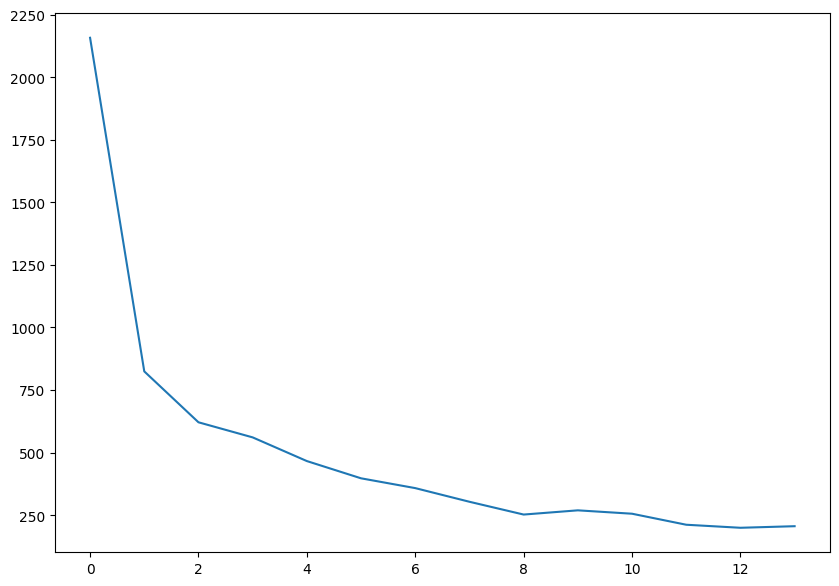

In [47]:
fig = plt.figure(figsize=(10,7))
plt.plot(np.arange(len(losses)), losses)
plt.show()

In [57]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

with torch.no_grad():
  for data in testloader:
    images, labels = data
    y_pred = net(images.to(device))
    _, predicted = torch.max(y_pred, 1)

    c = (predicted.cpu().detach() == labels) #на GPU получили предсказание, а далее работаем с CPU
    for i in range(4):
      label = labels[i]
      class_correct[label] += c[i].item()
      class_total[label] += 1

for i in range(10):
  print(f'accuracy of {i}: {100 * class_correct[i] / class_total[i]}')

accuracy of 0: 94.48979591836735
accuracy of 1: 99.73568281938326
accuracy of 2: 97.86821705426357
accuracy of 3: 96.23762376237623
accuracy of 4: 99.59266802443992
accuracy of 5: 98.99103139013452
accuracy of 6: 97.59916492693111
accuracy of 7: 97.95719844357977
accuracy of 8: 94.25051334702259
accuracy of 9: 91.87314172447968


Пишем нейронку для CIFAR10

CIFAR10: это набор из 60k картинок 32х32х3, 50k которых составляют обучающую выборку, и оставшиеся 10k - тестовую. Классов в этом датасете 10: 'plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'.

In [73]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

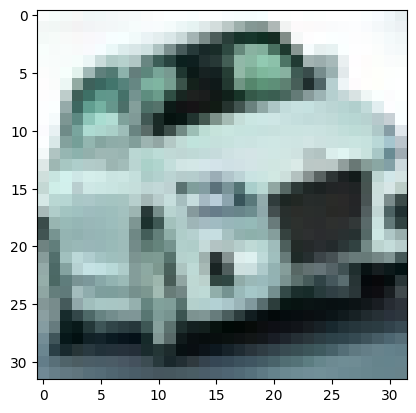

In [62]:
i = np.random.randint(low=0, high=50000)

img = trainloader.dataset.data[i]

plt.imshow(img, cmap='gray')

In [74]:
class MyConvNet(nn.Module):
  def __init__(self):
    super(MyConvNet, self).__init__()
    self.conv1 = torch.nn.Conv2d(in_channels=3, out_channels=64, kernel_size=5)
    self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2)
    self.conv2 = torch.nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3)
    self.fc1 = nn.Linear(128 * 6 * 6, 128)
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 10)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = x.view(-1, 128 * 6 * 6)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x


In [75]:
net = MyConvNet()

summary(net.cuda(), (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 28, 28]           4,864
         MaxPool2d-2           [-1, 64, 14, 14]               0
            Conv2d-3          [-1, 128, 12, 12]          73,856
         MaxPool2d-4            [-1, 128, 6, 6]               0
            Linear-5                  [-1, 128]         589,952
            Linear-6                   [-1, 64]           8,256
            Linear-7                   [-1, 10]             650
Total params: 677,578
Trainable params: 677,578
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.66
Params size (MB): 2.58
Estimated Total Size (MB): 3.25
----------------------------------------------------------------


In [76]:
net = MyConvNet().to(device)
loss_fn = nn.CrossEntropyLoss()
learning_rate=1e-4
optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)

In [85]:
losses = []
for epoch in tqdm(range(10)):
  running_loss = 0.0
  for i, batch in enumerate(tqdm(trainloader)):
    X_batch, y_batch = batch
    optimizer.zero_grad()
    y_pred = net(X_batch.to(device))
    loss = loss_fn(y_pred, y_batch.to(device))
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    if i % 100 == 99:
      losses.append(running_loss)
      running_loss = 0.0

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

...

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d2e09fb58a0>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7d2e09fb58a0>Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
self._shutdown_workers()    
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers

      if w.is_alive():
          ^ ^ ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
assert self._par

  0%|          | 0/391 [00:00<?, ?it/s]

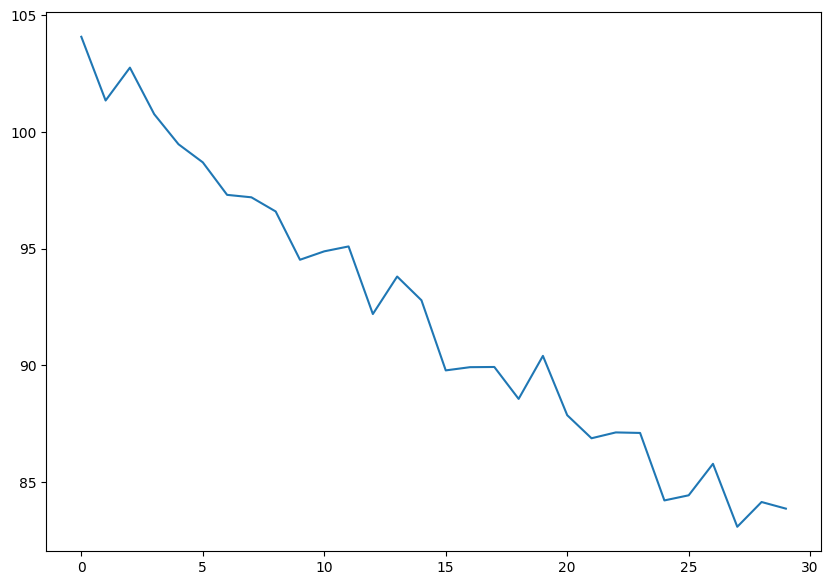

In [87]:
fig = plt.figure(figsize=(10,7))
plt.plot(np.arange(len(losses)), losses)
plt.show()

In [95]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

with torch.no_grad():
  for data in testloader:
    images, labels = data
    y_pred = net(images.to(device))
    _, predicted = torch.max(y_pred, 1)

    c = (predicted.cpu().detach() == labels).squeeze()
    for i in range(len(labels)):
      label = labels[i]
      class_correct[label] += c[i].item()
      class_total[label] += 1

for i in range(10):
  print(f'accuracy: {100 * class_correct[i] / class_total[i]} %')

accuracy: 75.8 %
accuracy: 73.5 %
accuracy: 53.2 %
accuracy: 52.8 %
accuracy: 60.2 %
accuracy: 59.6 %
accuracy: 78.0 %
accuracy: 73.7 %
accuracy: 79.3 %
accuracy: 77.2 %
